In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Keeps our notebook clean

# 1. Set the aesthetic theme
sns.set_theme(style="darkgrid")

# 2. Load the dataset (Make sure the CSV is in the same folder as this notebook!)
# Note: The exact filename might differ slightly based on your Kaggle download
df = pd.read_csv('startup_funding.csv')

# 3. Data Cleaning: The "Amount in USD" column has commas and NaN values.
# We need to strip the commas and convert it to float (decimals)
df['Amount in USD'] = pd.to_numeric(
    df['Amount in USD']
      .astype(str)
      .str.replace(',', '', regex=False)
      .str.strip()
      .str.lower()
      .replace({'nan': np.nan, 'none': np.nan, 'undisclosed': np.nan, 'not disclosed': np.nan, '': np.nan}),
    errors='coerce'
)

# 4. Data Cleaning: Convert the Date column to a proper Pandas DateTime object
df['Date dd/mm/yyyy'] = pd.to_datetime(df['Date dd/mm/yyyy'], errors='coerce')

# 5. Feature Engineering: Extract Year and Month for our time-series analysis
df['Year'] = df['Date dd/mm/yyyy'].dt.year
df['Month'] = df['Date dd/mm/yyyy'].dt.month

print("Data successfully loaded and cleaned!")

Data successfully loaded and cleaned!


In [10]:
# Look at the first 3 rows to confirm our cleaning worked
display(df.head(3))

# Check for missing values in every column
print("\n--- Missing Values ---")
display(df.isnull().sum())

# Get the mathematical summary of our funding amounts
display(df.describe())

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks,Year,Month
0,1,2020-09-01,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0,NaN,2020.0,9.0
1,2,NaT,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0,NaN,NaN,NaN
2,3,2020-09-01,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0,NaN,2020.0,9.0



--- Missing Values ---


Sr No                   0
Date dd/mm/yyyy      1752
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         979
Remarks              2625
Year                 1752
Month                1752
dtype: int64

,Sr No,Date dd/mm/yyyy,Amount in USD,Year,Month
count,3044.000000,1292,2.065000e+03,1292.000000,1292.000000
mean,1522.500000,2016-10-14 23:34:21.919504,1.842990e+07,2016.312693,6.541022
min,1.000000,2015-01-05 00:00:00,1.600000e+04,2015.000000,1.000000
25%,761.750000,2015-10-09 00:00:00,4.700000e+05,2015.000000,4.000000
50%,1522.500000,2016-08-04 00:00:00,1.700000e+06,2016.000000,7.000000
75%,2283.250000,2017-08-06 00:00:00,8.000000e+06,2017.000000,9.000000
max,3044.000000,2020-10-01 00:00:00,3.900000e+09,2020.000000,12.000000
std,878.871435,NaN,1.213734e+08,1.181339,3.411697


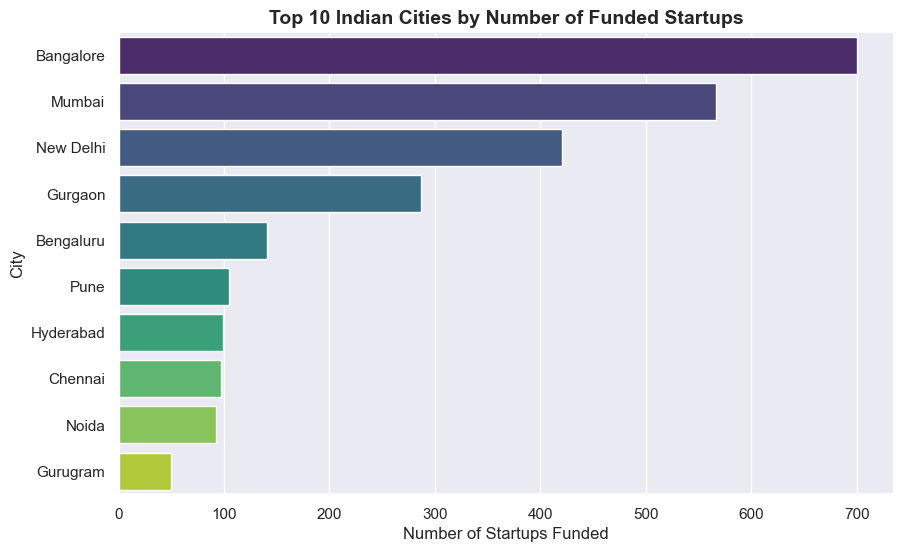

In [11]:
plt.figure(figsize=(10, 6))

# We use value_counts() to get the top 10 cities, then plot them
top_cities = df['City  Location'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')

plt.title("Top 10 Indian Cities by Number of Funded Startups", fontsize=14, fontweight='bold')
plt.xlabel("Number of Startups Funded")
plt.ylabel("City")
plt.show()

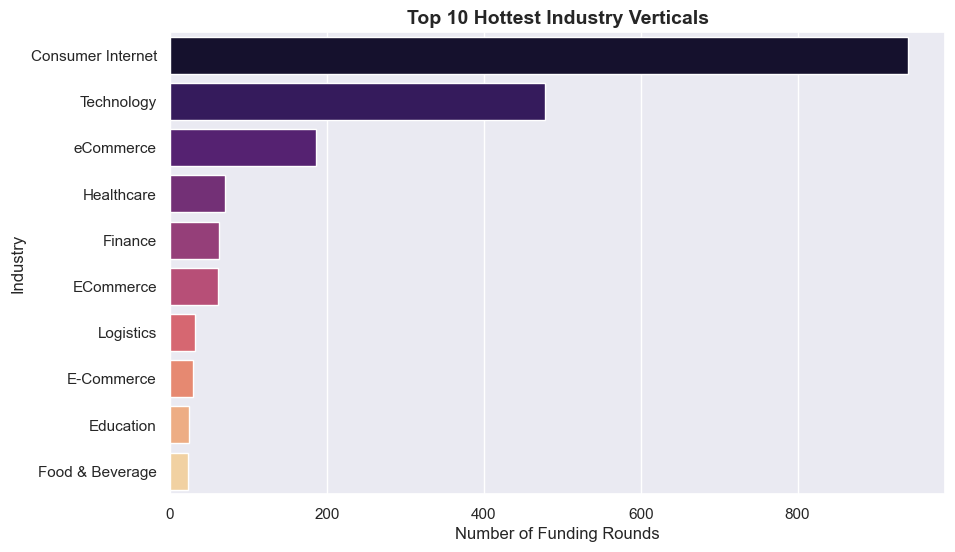

In [12]:
plt.figure(figsize=(10, 6))

top_industries = df['Industry Vertical'].value_counts().head(10)
sns.barplot(x=top_industries.values, y=top_industries.index, palette='magma')

plt.title("Top 10 Hottest Industry Verticals", fontsize=14, fontweight='bold')
plt.xlabel("Number of Funding Rounds")
plt.ylabel("Industry")
plt.show()

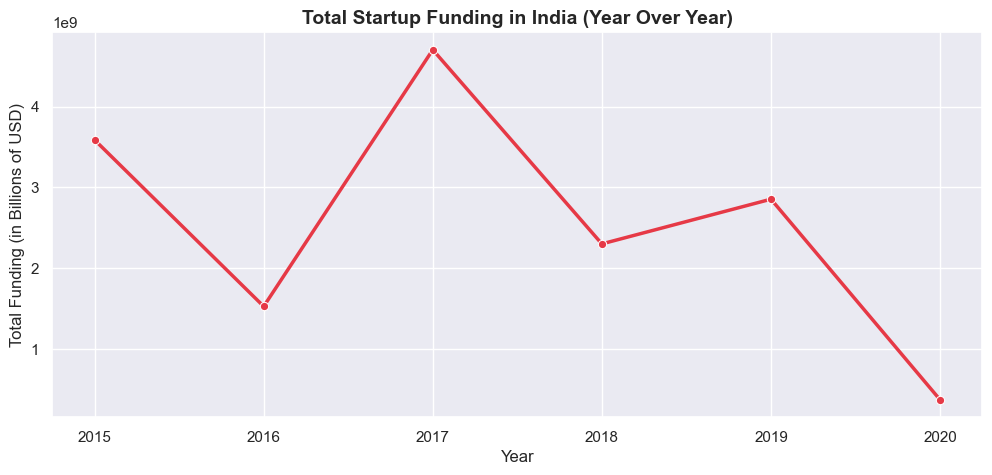

In [13]:
plt.figure(figsize=(12, 5))

# Group the data by Year and sum the total Amount in USD
yearly_funding = df.groupby('Year')['Amount in USD'].sum().reset_index()

sns.lineplot(data=yearly_funding, x='Year', y='Amount in USD', marker='o', color='#E63946', linewidth=2.5)

plt.title("Total Startup Funding in India (Year Over Year)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total Funding (in Billions of USD)")
plt.xticks(yearly_funding['Year']) # Ensures we only see whole years on the X-axis
plt.show()

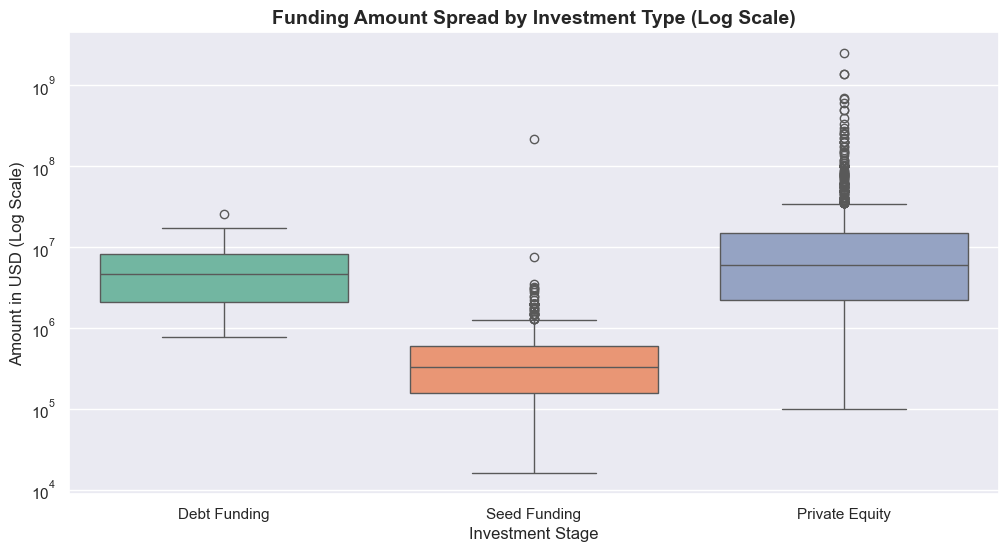

In [14]:
plt.figure(figsize=(12, 6))

# Filter to the most common investment types
common_types = ['Private Equity', 'Seed Funding', 'Debt Funding']
filtered_df = df[df['InvestmentnType'].isin(common_types)]

sns.boxplot(data=filtered_df, x='InvestmentnType', y='Amount in USD', palette='Set2')
plt.yscale('log') # Applies a logarithmic scale to the Y-axis to handle massive outliers

plt.title("Funding Amount Spread by Investment Type (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Investment Stage")
plt.ylabel("Amount in USD (Log Scale)")
plt.show()

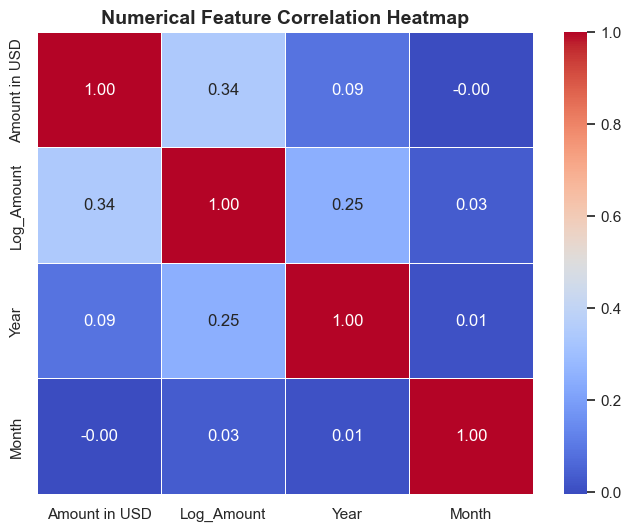

In [15]:
plt.figure(figsize=(8, 6))

# Create a temporary dataframe with just our numerical columns
df['Log_Amount'] = np.log1p(df['Amount in USD']) # Log transforms handle massive numbers better
numeric_df = df[['Amount in USD', 'Log_Amount', 'Year', 'Month']]

# Calculate correlation and plot
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Numerical Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()